# lab 4 - DVM dataset and F1_macro

## Дообучение двух предобученных классификаторов (ImageNet vs Places365)

### Подготовка данных

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim

from src.dataset import get_dataloaders
from src.models import CarColorClassifier, CarColorClassifierCustom
from src.trainer import ModelTrainer

from collections import Counter


# Настройки
DATA_DIR = './dataset'
BATCH_SIZE = 16
EPOCHS = 5 # Для финтьюнинга только последнего слоя 5 эпох обычно достаточно
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Загружаем данные и узнаем кол-во цветов
train_loader, val_loader = get_dataloaders(DATA_DIR, batch_size=BATCH_SIZE)

# Вытаскиваем датасет из лоадера
current_dataset = train_loader.dataset

# Считаем количество меток
counts = Counter(current_dataset.targets)

print(f"{'ID':<10} | {'Color':<20} | {'Count':<6}")
print("-" * 45)

NUM_CLASSES = len(current_dataset.classes)
for idx in range(NUM_CLASSES):
    color_name = current_dataset.classes[idx]
    num_images = counts[idx]
    print(f"{idx:<10} | {color_name:<20} | {num_images:<6}")

print("-" * 45)
print(f"Found {NUM_CLASSES} color classes with total {sum(counts.values())} images for train mode")
print(f"Using device: {DEVICE}")

ID         | Color                | Count 
---------------------------------------------
0          | Black                | 500   
1          | Blue                 | 500   
2          | Brown                | 500   
3          | Green                | 500   
4          | Grey                 | 500   
5          | Red                  | 500   
6          | Silver               | 500   
7          | Unlisted             | 500   
8          | White                | 500   
9          | Yellow               | 500   
---------------------------------------------
Found 10 color classes with total 5000 images for train mode
Using device: cuda:0


In [ ]:
from torchvision import models

CRITERION = nn.CrossEntropyLoss()

print("=== Training Model A: ResNet18 (ImageNet) ===")
# Создаем модель, замораживаем backbone
model_imagenet = CarColorClassifier(
    backbone=models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1),
    num_classes=NUM_CLASSES,
    freeze_backbone=True)

# Оптимизатор (учим ТОЛЬКО последний слой, поэтому параметры только fc)
optimizer_imagenet = optim.Adam(model_imagenet.backbone.fc.parameters(), lr=0.001)

history_imagenet = ModelTrainer(model_imagenet, DEVICE, CRITERION, optimizer_imagenet) \
                    .train(train_loader, val_loader, num_epochs=EPOCHS)

=== Training Model A: ResNet18 (ImageNet) ===


Epoch 1/5 | Train Loss: 1.6362 F1: 0.4407 | Val Loss: 2.7402 F1: 0.1410


Epoch 2/5 | Train Loss: 1.2257 F1: 0.5828 | Val Loss: 3.2127 F1: 0.1419


Epoch 3/5 | Train Loss: 1.1461 F1: 0.5946 | Val Loss: 3.3149 F1: 0.1534


Epoch 4/5 | Train Loss: 1.0729 F1: 0.6210 | Val Loss: 3.4636 F1: 0.1445


Epoch 5/5 | Train Loss: 1.0495 F1: 0.6359 | Val Loss: 3.4733 F1: 0.1472
Training complete in 140s. Best Val F1: 0.1534


In [6]:
import os

print("\n=== Training Model B: ResNet18 (Places365) ===")
# Создаем модель Б
# 1. Создаем "голую" архитектуру ResNet18 без предобучения ImageNet
model_resnet18 = models.resnet18(weights=None)
num_ftrs = model_resnet18.fc.in_features
model_resnet18.fc = torch.nn.Linear(num_ftrs, 365)

# 2. Скачиваем файл весов Places365, если его еще нет в Colab
checkpoint_file = 'resnet18_places365.pth.tar'
if not os.path.exists(checkpoint_file):
    print("Loading Places365 weights from MIT servers...")
    url = 'http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar'
    torch.hub.download_url_to_file(url, checkpoint_file)

# 3. Загружаем веса из файла
checkpoint = torch.load(checkpoint_file, map_location=DEVICE)
state_dict = {k.replace('module.', ''): v for k, v in checkpoint['state_dict'].items()}
model_resnet18.load_state_dict(state_dict)

# 4. Теперь оборачиваем эту базу в наш класс CarColorClassifier
# Мы передаем готовую предобученную модель как backbone
model_places365 = CarColorClassifier(model_resnet18, num_classes=NUM_CLASSES, freeze_backbone=True)

optimizer_places365 = optim.Adam(model_places365.backbone.fc.parameters(), lr=0.001)

history_places365 = ModelTrainer(model_places365, DEVICE, criterion, optimizer_places365) \
                     .train(train_loader, val_loader, num_epochs=EPOCHS)


=== Training Model B: ResNet18 (Places365) ===


Epoch 1/5 | Train Loss: 1.6919 F1: 0.4299 | Val Loss: 2.6387 F1: 0.1404


Epoch 2/5 | Train Loss: 1.3190 F1: 0.5395 | Val Loss: 2.9871 F1: 0.1586


Epoch 3/5 | Train Loss: 1.2264 F1: 0.5736 | Val Loss: 3.1750 F1: 0.1436


Epoch 4/5 | Train Loss: 1.1514 F1: 0.5944 | Val Loss: 3.2507 F1: 0.1332


Epoch 5/5 | Train Loss: 1.1442 F1: 0.5907 | Val Loss: 3.3680 F1: 0.1469
Training complete in 146s. Best Val F1: 0.1586


## Собственный классификатор

### Архитектура

Модель построена по классическому принципу CNN.

**Три сверточных блока (Layer 1, 2, 3):**

1. Первый слой видит простые линии и базовые цвета.
2. Второй — простые формы (фары, колеса).
3. Третий — сложные текстуры и комбинации цветов.

Чем глубже, тем более абстрактные признаки извлекает сеть.

**Рост количества фильтров (32 -> 64 -> 128)**

Мы уменьшаем пространственное разрешение картинки, но увеличиваем «глубину» признаков, чтобы сеть знала много деталей о маленьком представлении изображения.

**BatchNorm2d**

Это "стабилизатор". Он нормализует выходы слоев, чтобы веса не "взрывались" и обучение шло быстрее.

**MaxPool2d**

Уменьшает размер картинки в 2 раза, чтобы экономить память видеокарты (у тебя 4 ГБ, это важно!) и увеличивать "поле зрения" следующих слоев.

**nn.Flatten() + Linear(128 * 28 * 28, 512)**

Превращаем 2D-карты признаков в плоский вектор. 512 нейронов — это "мозг" классификатора, который принимает решение на основе всех найденных признаков.

**Dropout(0.5)**

Случайно «выключает» половину нейронов в процессе обучения. Это заставляет сеть не полагаться на одну конкретную деталь (например, только на форму фары), а учить общие признаки цвета. Защита от переобучения.


**Реализация лежит в [models.py](src/models.py).*

In [ ]:
print("\n=== Training Model C: Custom CNN (From Scratch) ===")

# 1. Инициализируем модель
model_custom = CarColorClassifierCustom(num_classes=NUM_CLASSES)

# 2. Оптимизатор. Здесь мы передаем ВСЕ параметры модели (model_custom.parameters())
# т.к. учим всё с нуля.
optimizer_custom = optim.Adam(model_custom.parameters(), lr=0.001)

# 3. Запускаем обучение
# Для кастомной модели с нуля может понадобиться чуть больше эпох, чем для ResNet
history_custom = ModelTrainer(model_custom, DEVICE, CRITERION, optimizer_custom) \
                        .train(train_loader, val_loader, num_epochs=10)


=== Training Model C: Custom CNN (From Scratch) ===


Epoch 1/10 | Train Loss: 4.1962 F1: 0.2126 | Val Loss: 3.7974 F1: 0.0358


Epoch 2/10 | Train Loss: 2.0129 F1: 0.1805 | Val Loss: 5.6514 F1: 0.0390


Epoch 3/10 | Train Loss: 2.0017 F1: 0.1945 | Val Loss: 6.3507 F1: 0.0399


Epoch 4/10 | Train Loss: 2.0209 F1: 0.1795 | Val Loss: 4.3629 F1: 0.0305


...

Epoch 6/10 | Train Loss: 2.0567 F1: 0.1725 | Val Loss: 3.9835 F1: 0.0400


Epoch 7/10 | Train Loss: 2.0139 F1: 0.1980 | Val Loss: 3.4486 F1: 0.0346


Epoch 8/10 | Train Loss: 1.9853 F1: 0.2090 | Val Loss: 5.2569 F1: 0.0399


Epoch 9/10 | Train Loss: 1.9784 F1: 0.1874 | Val Loss: 3.3273 F1: 0.0544


Epoch 10/10 | Train Loss: 2.0239 F1: 0.1924 | Val Loss: 3.8874 F1: 0.0401
Training complete in 458s. Best Val F1: 0.0544


## Качество моделей по F1_macro

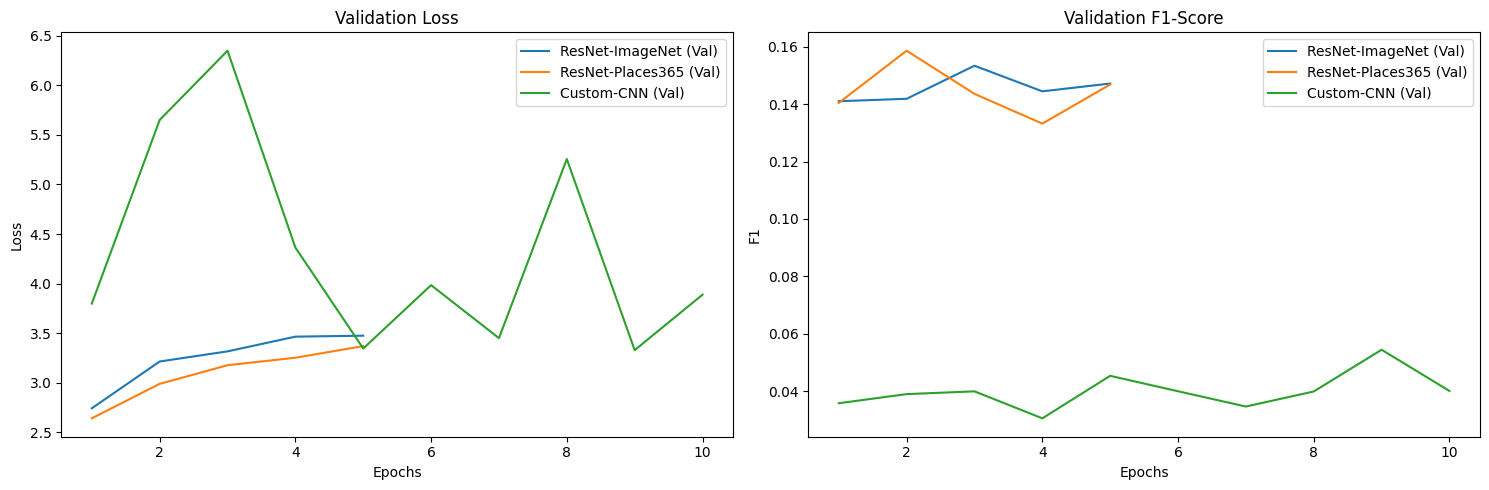

In [ ]:
import matplotlib.pyplot as plt

def plot_results(histories, model_names, scope='val'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    for history, name in zip(histories, model_names):
        epochs = range(1, len(history[f'{scope}_loss']) + 1)
        
        # График Loss
        ax1.plot(epochs, history[f'{scope}_loss'], label=f'{name}')
        ax1.set_title(f'{scope} Loss')
        ax1.set_xlabel('Epochs')
        ax1.set_ylabel('Loss')
        ax1.legend()
        
        # График F1_macro
        ax2.plot(epochs, history[f'{scope}_f1'], label=f'{name}')
        ax2.set_title(f'{scope} F1_macro')
        ax2.set_xlabel('Epochs')
        ax2.set_ylabel('F1')
        ax2.legend()
    
    plt.tight_layout()
    plt.show()


plot_results([history_imagenet, history_places365, history_custom],
             ['ResNet-ImageNet', 'ResNet-Places365', 'Custom-CNN'])

plot_results([history_imagenet, history_places365, history_custom],
             ['ResNet-ImageNet', 'ResNet-Places365', 'Custom-CNN'])

## Вывод

### 1. Качество данных

Такие низкие показатели точности связаны с качеством датасета. Анализ показал высокую степень зашумленности. Например, в классе Green присутствуют автомобили золотистого, бежевого и желто-зеленого оттенков. Это создает "непреодолимую" сложность для моделей с замороженным backbone.
<img src="img/green.png" width="30%"> <img src="img/blue.png" width="30%"> <img src="img/black.png" width="30%">

### Сравнение признаков

Несмотря на то, что ResNet-Places365 продемонстрировала наименьшее значение потерь, её точность оказалась нестабильной. Пиковое значение F1_macro было достигнуто на 2-й эпохе, после чего началось падение, что указывает на быструю деградацию обобщающей способности из-за специфики весов, ориентированных на ландшафты, а не на объекты. В весах же Resnet-ImageNet уже заложены фильтры для распознавания объектов. Модель Places365, ориентированная на ландшафты, хуже справляется с мелкими деталями автомобилей.

Прыжки кастомной модели можно объяснить следующими нюансами
- learning rate слишком высокий - модель «перепрыгивает» через локальные минимумы;
- маленький batch size - каждый новый кусок данных слишком сильно меняет веса;
- шум в данных - модель пытается их выучить, сходит с ума, и веса «взрываются».

Поиграв с learning rate, batch size и подчистив датасет, можно получить более качественное обучение на выходе не только для кастомной, но и для всех моделей

### Проблема переобучения

Из-за малого объема качественных данных и шума в разметке, модели быстро переходят к "зубрежке" тренировочных данных, что подтверждается ростом Loss на валидации при падении Loss на обучении.

Собственная архитектура: Созданная с нуля сверточная сеть не смогла достичь показателей предобученных моделей, что подтверждает эффективность концепции Transfer Learning для прикладных задач с ограниченным датасетом.

In [ ]:
## 